In [1]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import cmasher as cmr
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
import importlib
sys.path.append('../code/')
import helper

## Save Phase Angles

In [2]:
def save_phase_coefs(directory, channel_file, n_channels, j_bins=20, start_timestep=0, end_timestep=None):
    file = np.loadtxt(directory+channel_file)
    n_times = file.shape[0]
    if end_timestep==None:
        times = np.reshape(file[start_timestep:,0], (n_times-start_timestep,1))
    else:
        times = np.reshape(file[start_timestep:end_timestep,0], (end_timestep-start_timestep,1))
    
    m1_phase_coefs = file[start_timestep:end_timestep,5*n_channels+1:6*n_channels+1]# - 16*5]
    m2_phase_coefs = file[start_timestep:end_timestep,6*n_channels+1:7*n_channels+1]# - 16*5]
    
    m1_phase = np.concatenate([times, m1_phase_coefs], axis=1)
    m2_phase = np.concatenate([times, m2_phase_coefs], axis=1)
    
    fname_prefix = directory+'mSSA_channels_Kiyan_test_t40-300/'
    np.savetxt(fname_prefix + 'm1_phase_bins_j{}_t16.dat'.format(j_bins), m1_phase)
    np.savetxt(fname_prefix + 'm2_phase_bins_j{}_t16.dat'.format(j_bins), m2_phase)

In [3]:
tbl = Table.read('../data/kiyan-mssa_prep_table_with_time.fits')
tbl.sort(["timestep", "jphi_cen", "tphi_cen"])

In [4]:
jphi_c = np.linspace(1000, 3000, 20+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
centers = np.array(np.meshgrid(jphi_c, tphi_c)).T.reshape(-1,2)

cfs_m0_amp    = ['m0_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_amp    = ['m1_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_amp    = ['m2_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_pitch  = ['m1_pitch_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_pitch  = ['m2_pitch_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_phase  = ['m1_phase_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_phase  = ['m2_phase_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]

colnames = ['timestep']+cfs_m0_amp+cfs_m1_amp+cfs_m2_amp+cfs_m1_pitch+cfs_m2_pitch+cfs_m1_phase+cfs_m2_phase

t = Table(names=colnames)

for time in np.unique(tbl['timestep']):
    subset = tbl[tbl['timestep'] == time]
    channels = np.concatenate([np.array(subset['m0_amp']), np.array(subset['m1_amp']), np.array(subset['m2_amp']),
                                    np.array(subset['pitch_ang_m1']), np.array(subset['pitch_ang_m2']), 
                                    np.array(subset['phase_ang_m1']), np.array(subset['phase_ang_m2'])])
    #amps = np.concatenate((subset['m1_amp'], subset['m2_amp']))
    t.add_row(np.append([time], channels))

# np.savetxt('../data/kiyan-fast_for_mssa.dat', t)

In [5]:
file = np.loadtxt('../data/kiyan-test_for_mssa.dat')

In [40]:
file.shape

(300, 3025)

In [41]:
3024/7

432.0

In [42]:
save_phase_coefs(directory='../data/', channel_file='kiyan-test_for_mssa.dat', 
           n_channels=336, j_bins=20, start_timestep=38, end_timestep=110)

### Loading in Files

In [6]:
directory = '../data/mSSA_channels_Kiyan_test_t40-300/'

fname_m1_phase = directory+'m1_phase_bins_j20_t16.dat'

coefs_m1_phase0 = pyEXP.coefs.Coefs.factory(fname_m1_phase)

coefs_m1_phase = coefs_m1_phase0.deepcopy()

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [7]:
# A list with three keys.  Keys are integer arrays (or lists).  
# The first column of the data table has the key [0], etc.
#keylst = [[i] for i in range(len(coefs.getAllCoefs()))]

n_channels = int(len(coefs_m1_phase.getAllCoefs()))
times = coefs_m1_phase.Times()

keylst_m1_amp = [[i] for i in range(n_channels)]
keylst_m1_pitch = [[i] for i in range(n_channels)]
keylst_m1_phase = [[i] for i in range(n_channels)]
keylst_m2_amp = [[i] for i in range(n_channels)]
keylst_m2_pitch = [[i] for i in range(n_channels)]

config = {"snails_m1_phase": (coefs_m1_phase, keylst_m1_phase, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

---- Eigen is using 4 threads


In [8]:
fig_dir = '../figures/kiyan_test_figures/m1_phase/'

In [9]:
ev = mssa.eigenvalues()

shape U = 12096 x 37
shape Y = 37 x 12096


In [20]:
coefs_m1_phase.zerodata()
mssa.reconstruct([*range(30)])

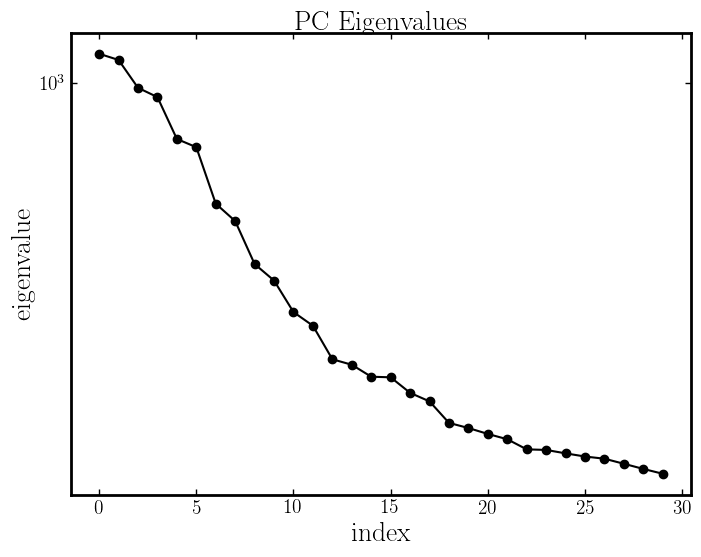

In [21]:
%matplotlib inline
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

ax1.semilogy(ev[:30], '-o')

ax1.set_xlabel('index', fontsize=20)
ax1.set_ylabel('eigenvalue', fontsize=20)
    
ax1.set_title('PC Eigenvalues', fontsize=20)
#plt.savefig(fig_dir+'eigenvalues.pdf')
#plt.savefig(fig_dir+'eigenvalues.png')
plt.show()

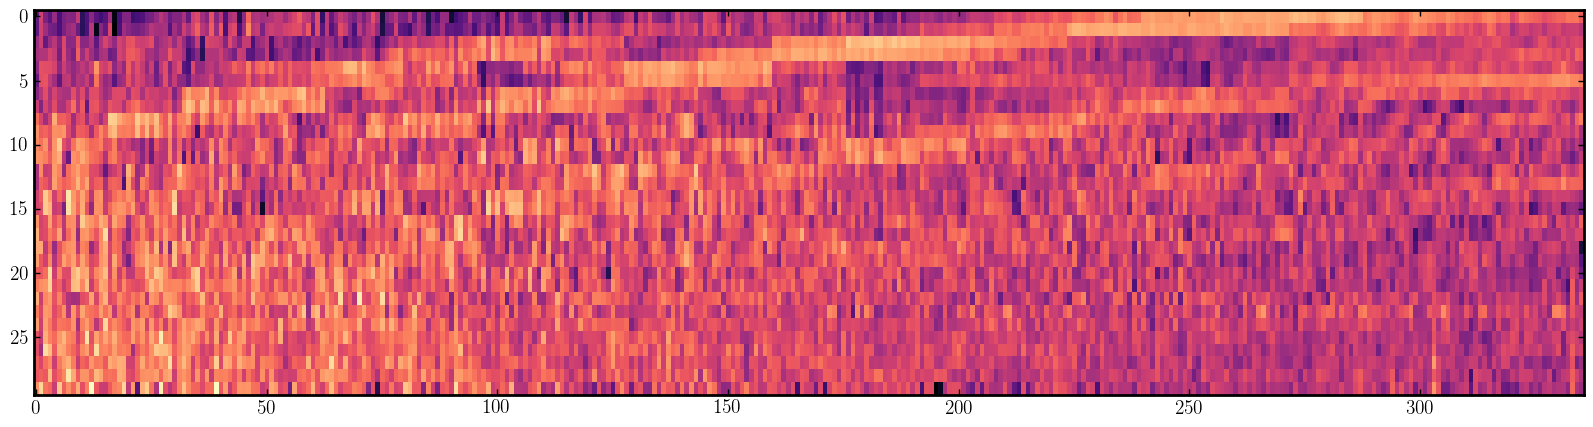

In [22]:
t1, t2 = mssa.contrib()
plt.figure(figsize=(20, 5))
plt.imshow(t2, aspect='auto', norm=mpl.colors.LogNorm())

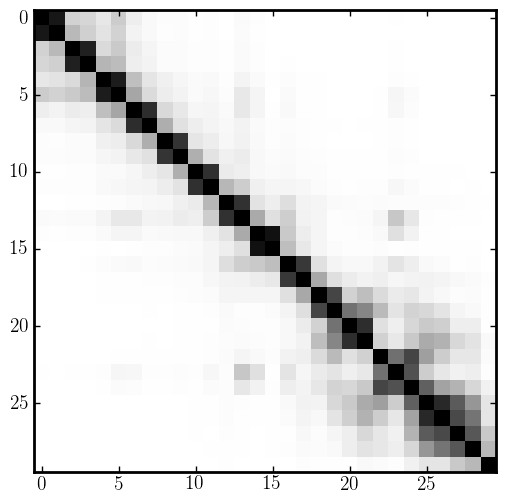

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(6,6), sharey=True)

ax.imshow(mssa.wCorrAll()[:30, :30], cmap='gray_r')
#plt.savefig(fig_dir+'wCorr30.pdf')
#plt.savefig(fig_dir+'wCorr30.png') 
plt.show()

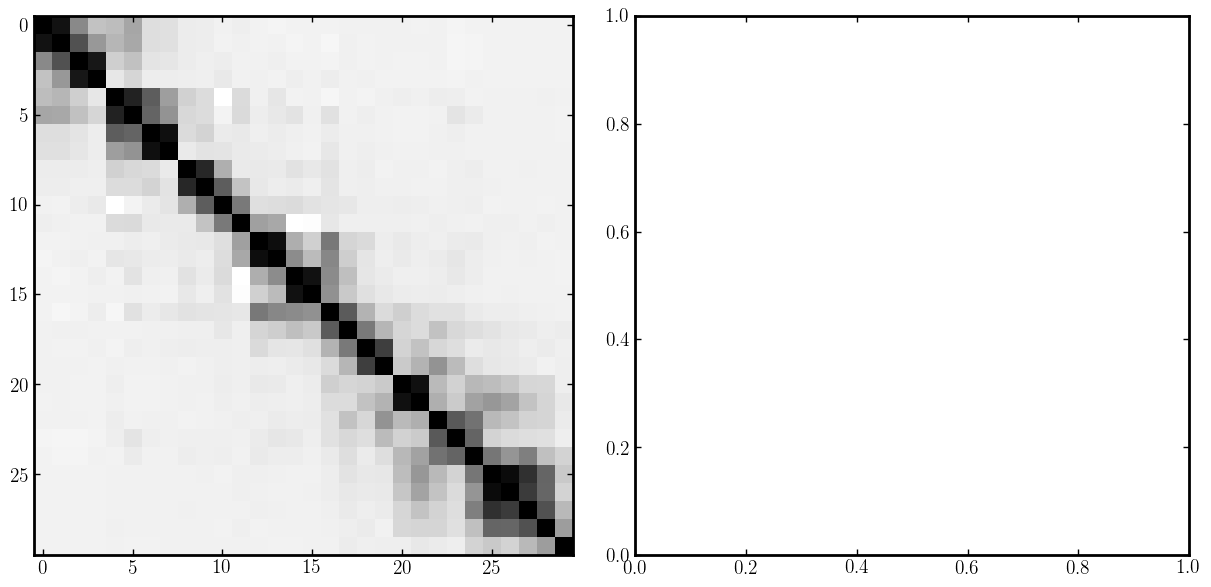

In [27]:
# wCorr for amplitude:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15,7))
ax1.imshow(mssa.wCorrKey([0]), cmap='gray_r')
#ax2.imshow(mssa.wCorrKey([1]), cmap='gray_r')
plt.show()

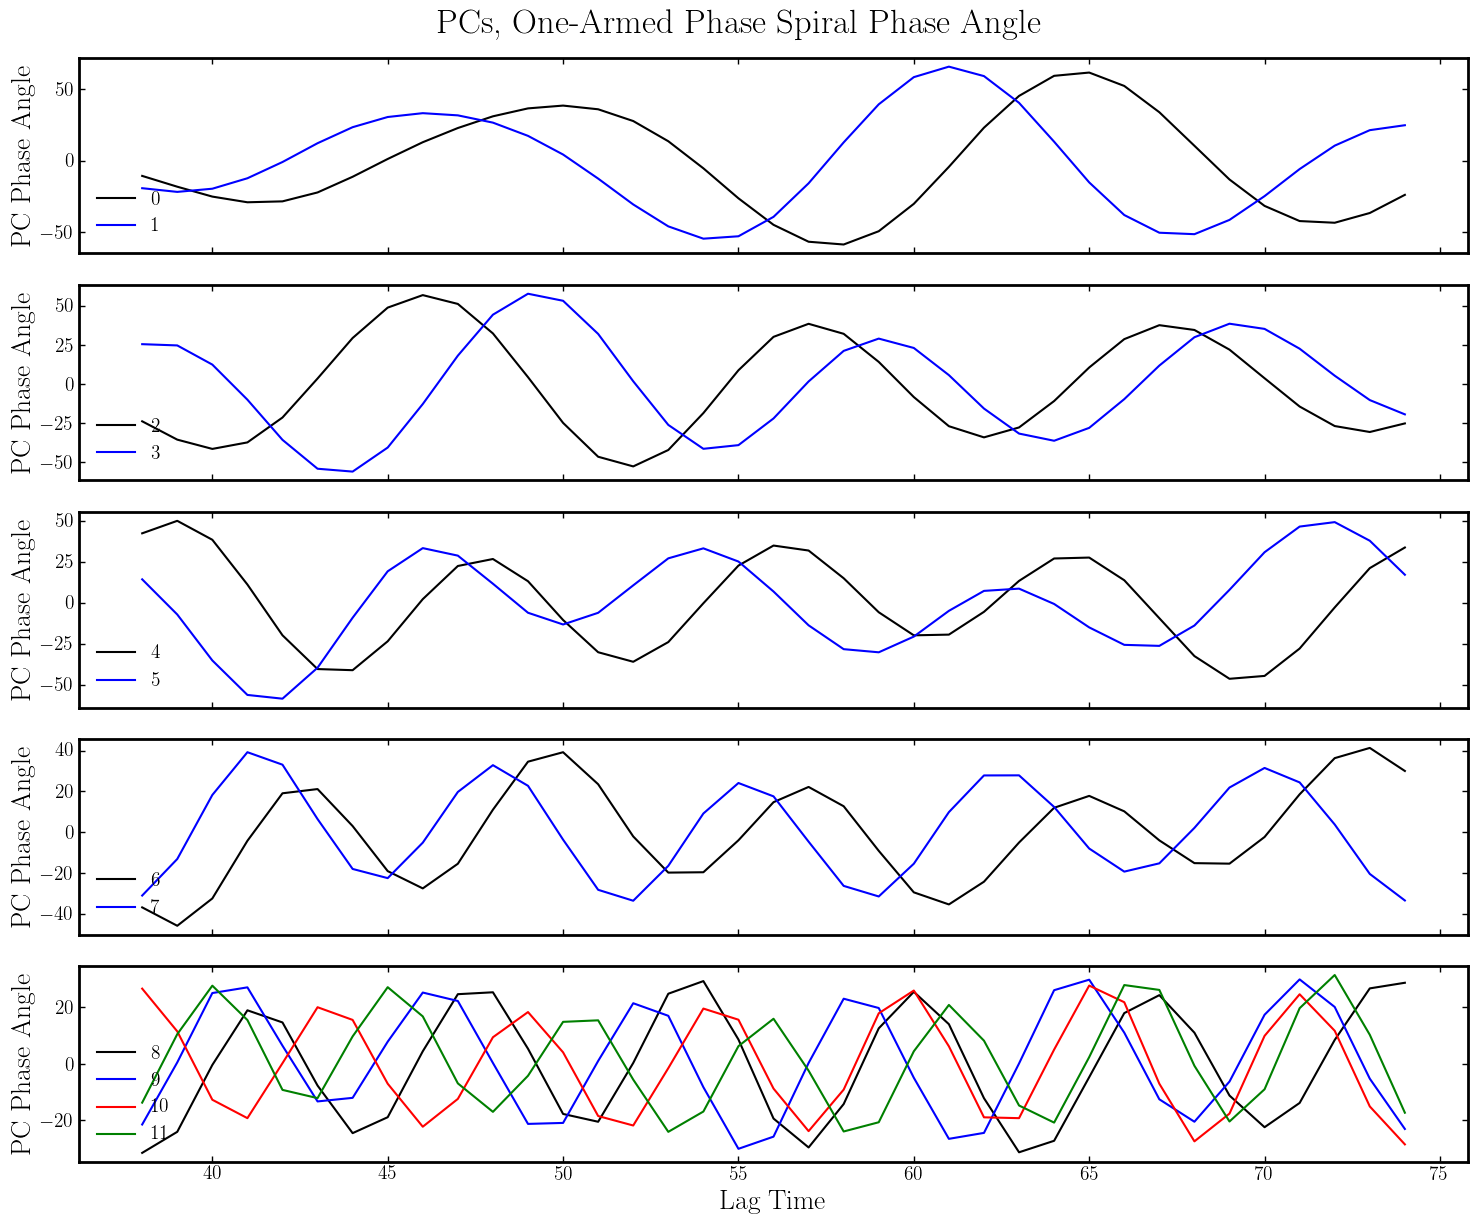

In [28]:
%matplotlib inline
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(15, 2.5*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

plt.suptitle('PCs, One-Armed Phase Spiral Phase Angle', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

for i in range(n_plots):
    axs[i].set_ylabel('PC Phase Angle', fontsize=20)
    axs[i].legend(fontsize=14, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
#plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

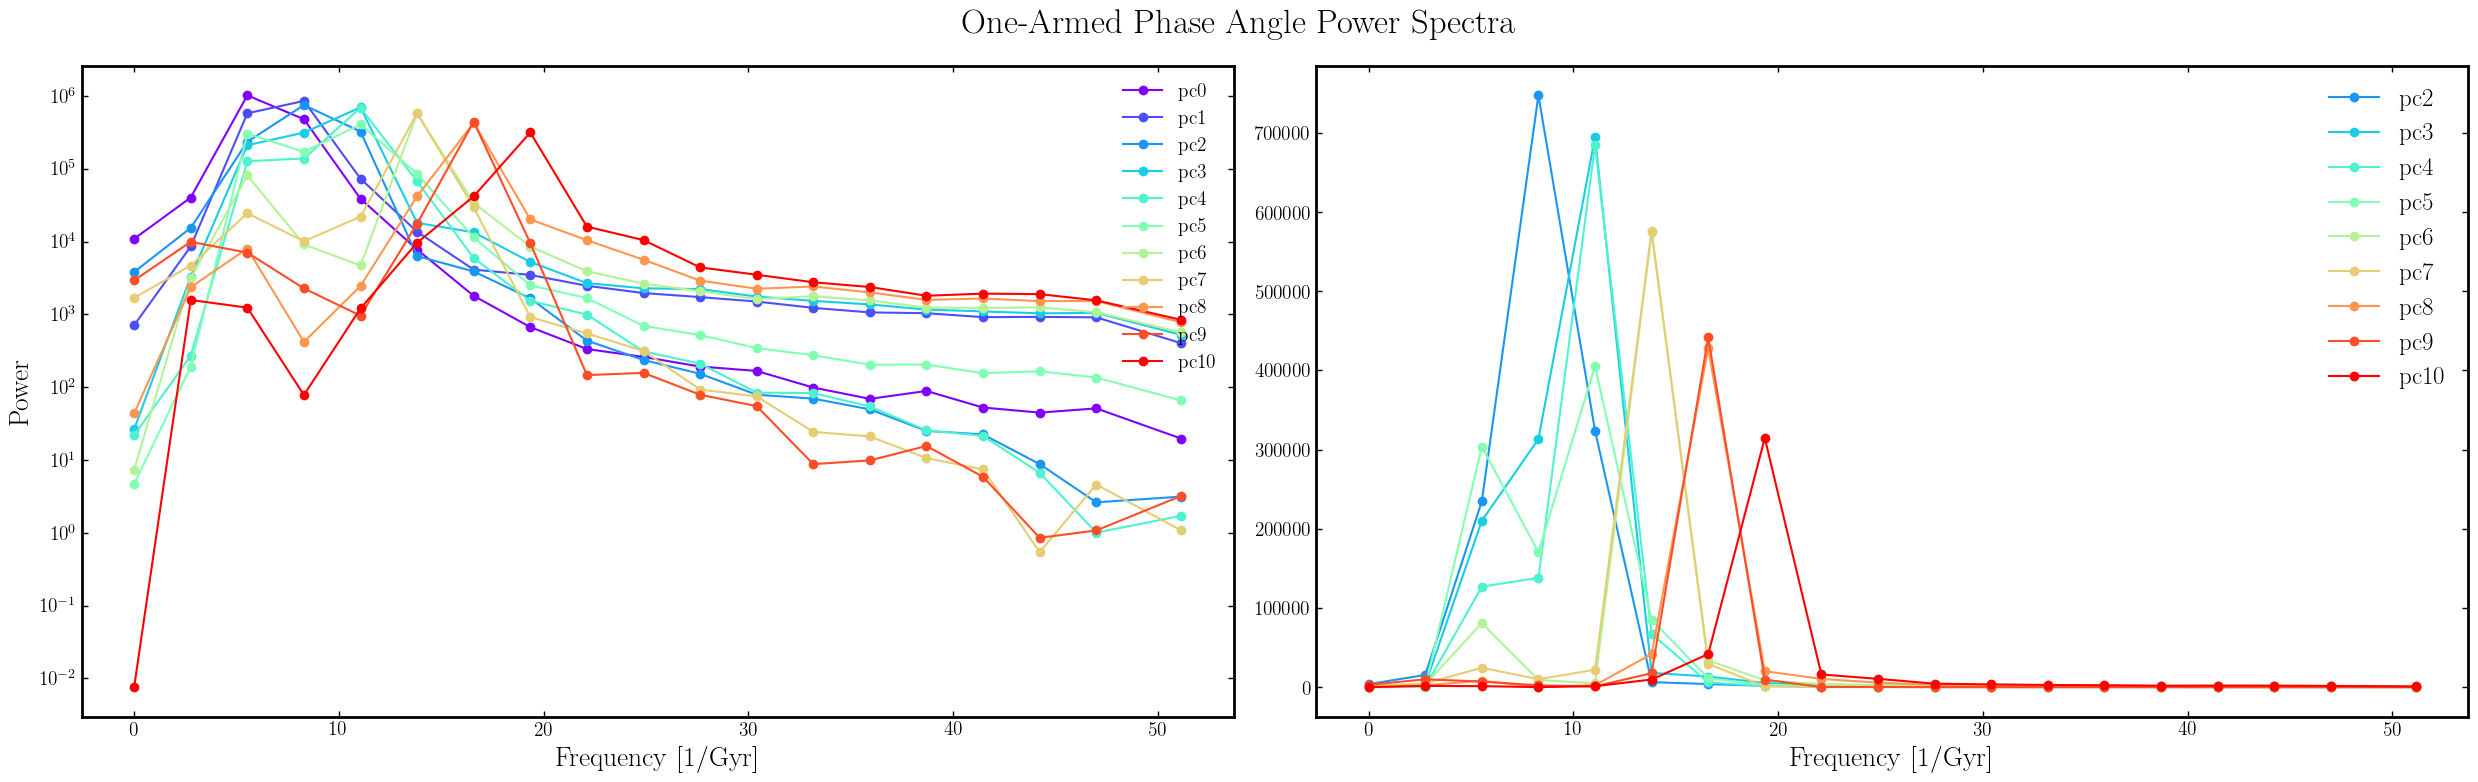

In [54]:
freq, power = mssa.pcDFT()
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(25, 8))

color = iter(cm.rainbow(np.linspace(0, 1, 11)))
    
for i in range(0, 11,1):
    c = next(color)
    ax1.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

    if i>=2:
        ax2.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

ax1.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax2.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax1.legend() ; ax2.legend(fontsize=18)
ax1.set_ylabel('Power', fontsize=20)
ax1.set_yscale('log')

plt.suptitle('One-Armed Phase Angle Power Spectra', fontsize=25)
fig.tight_layout()
#plt.savefig(fig_dir+'power_spectrum.pdf')
plt.show()

### Face-on Plots

Updating for: (c)_0
Updating for: (s)_0
Updating for: (`)_0
Updating for: (
)_0
Updating for: (�)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
336
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (~)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (~)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (P)_0
Updating for: ()_0
Updating for: (9)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( 

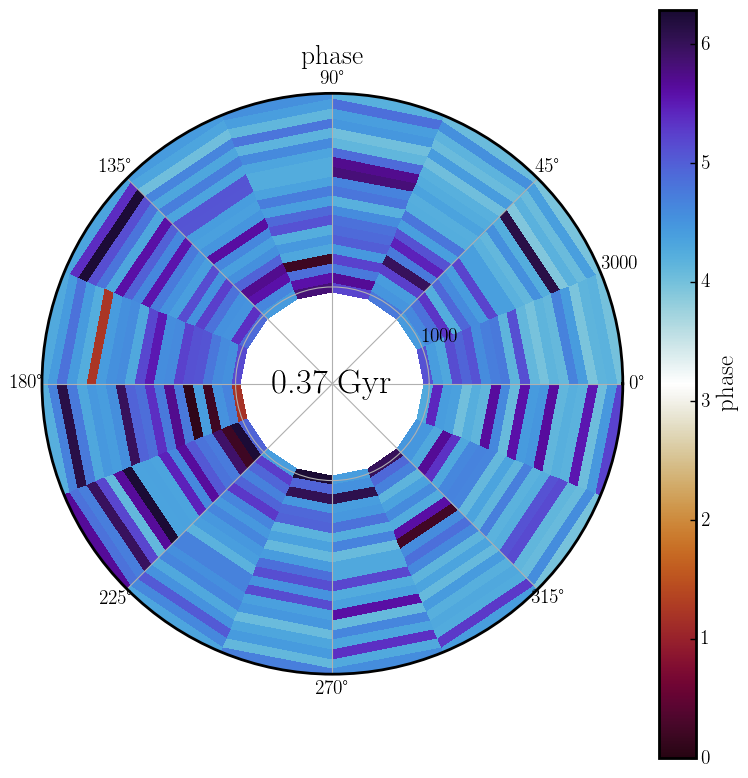

In [57]:
importlib.reload(sys.modules['helper'])
from helper import *

tbl_phase = np.loadtxt(directory+'m1_phase_bins_j20_t16.dat')

f = fig_dir+'face-on_plots/data_m1_phase.mp4'
f_sub = fig_dir+'face-on_plots/data_m1_phase_subtract_pc0-1.mp4'

tdict = {'phase': tbl_phase}
MakeAnim = MakeAnimations(mssa, 'phase', times, n_channels, [0,1], jbins=20)
MakeAnim.make_pre_mssa_face_on(f, tdict)
# MakeAnim.make_pre_mssa_face_on_subtracted(f_sub, tbl_phase, tbl_phase)

Updating for: (c)_0
Updating for: (s)_0
Updating for: (p)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
336
Making movies for just Amplitude or Pitch Angle
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (~)_0
Updating for: (�)_0
Updating for: (")_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (v)_0
Updating for: ( )_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (!)_0
Updating for: (")_0
Updating for: ()_0
Updating

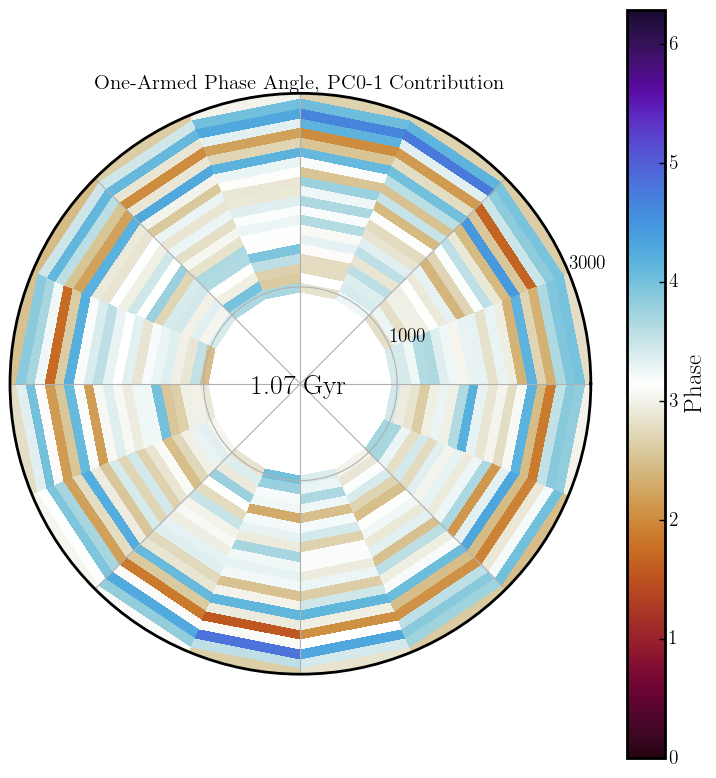

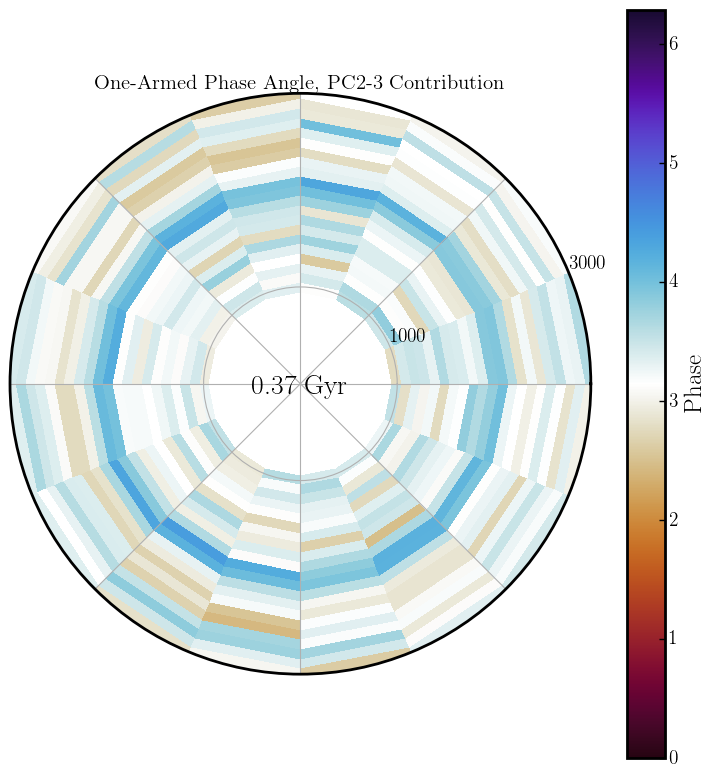

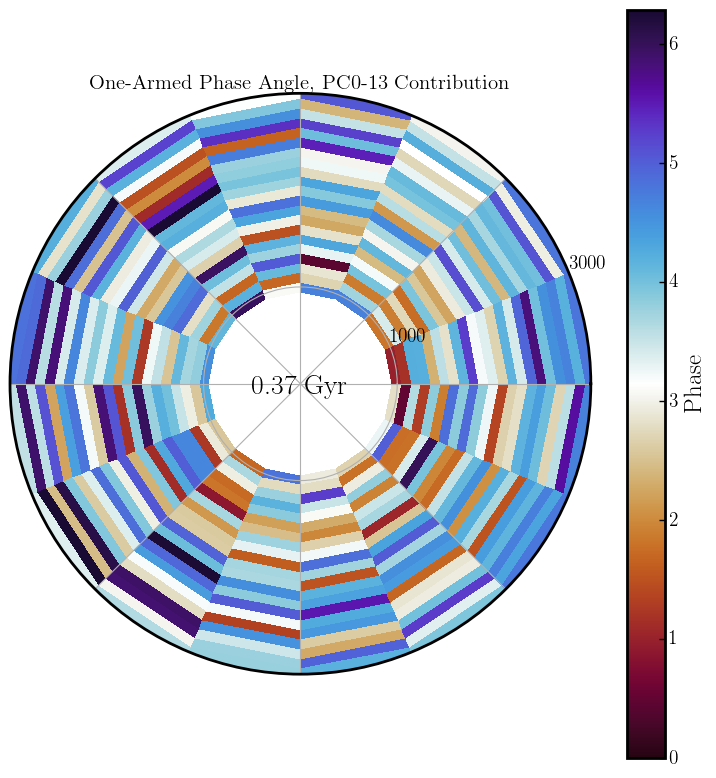

In [110]:
importlib.reload(sys.modules['helper'])
from helper import *

f = fig_dir+'face-on_plots/m1_phase_pc0+pc1.mp4'
MakeAnim0 = MakeAnimations(mssa, 'phase', times, n_channels, [0,1], jbins=20)
MakeAnim0.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/m1_phase_pc2+pc3.mp4'
MakeAnim1 = MakeAnimations(mssa, 'phase', times, n_channels, [2,3], jbins=20)
MakeAnim1.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/m1_phase_pc0-13.mp4'
MakeAnim2 = MakeAnimations(mssa, 'phase', times, n_channels, list(range(0,14)), jbins=20)
MakeAnim2.make_recon_mov_disk_plot(f)

We get the ridges we expect but they dissipate very quickly. This is partly due to the fact that Jz at which I am taking the angle is low, meaning the oscialltions in the vertical direction occur quickly and the signal is washed out. There should be a way to convert analytically such that we artificially create a dataset that is the equivalent of taking a higher Jz as the critical point.

## For Widmark+25

In [52]:
tbl = Table.read('../data/kiyan-mssa_prep_table_with_time.fits')['timestep','jphi_cen','tphi_cen','phase_ang_m1','pitch_ang_m1']
tbl.sort(["timestep", "jphi_cen", "tphi_cen"])

In [53]:
tbl

timestep,jphi_cen,tphi_cen,phase_ang_m1,pitch_ang_m1
float64,float64,float64,float64,float64
0.0,1000.0,0.19634954084936207,3.1371400127445668,-0.1690234984860178
0.0,1000.0,0.5890486225480862,0.15289611561975358,-0.20722284944748004
0.0,1000.0,0.9817477042468103,2.5351717354182846,-0.2208681172690919
0.0,1000.0,1.3744467859455345,5.1726743419375865,-1.5707963267805602
0.0,1000.0,1.7671458676442586,1.7503598445786963,-0.0714795013587431
0.0,1000.0,2.1598449493429825,4.910507598192218,-0.1569266894214623
0.0,1000.0,2.552544031041707,1.6608069223998623,-1.5707963267948921
0.0,1000.0,2.945243112740431,0.8460500063065817,-1.3425885306347924
0.0,1000.0,3.3379421944391554,2.319306462947999,-0.11736090508326152


In [49]:
tbl_time_sub = tbl[tbl['timestep']==55]

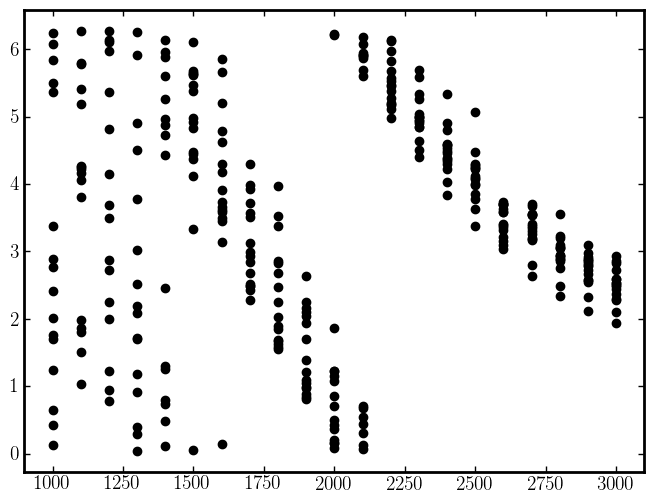

In [50]:
plt.scatter(tbl_time_sub['jphi_cen'], tbl_time_sub['phase_ang_m1'], )

In [67]:
jz_scale_radii = np.array([4.53510432, 4.47865548, 4.38203796, 4.27667758, 4.16081745,
       4.0282477 , 3.90484369, 3.77483637, 3.6213122 , 3.40904482,
       3.24482099, 3.06878344, 2.9250978 , 2.75589906, 2.62840193,
       2.46301566, 2.35747128, 2.20033958, 2.09821908, 2.12319181,
       2.20874953])

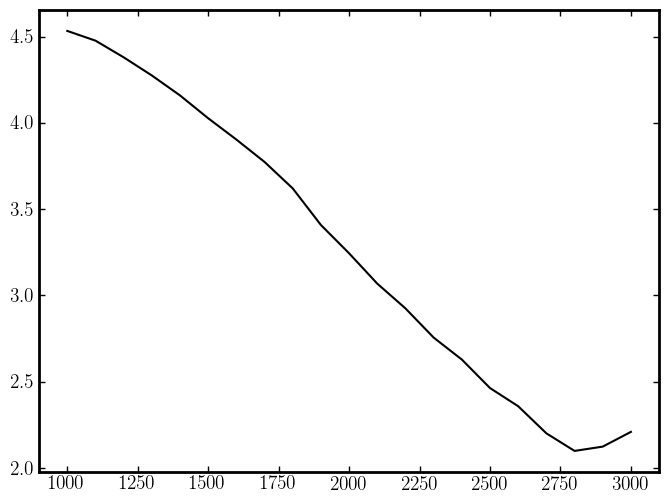

In [69]:
plt.plot(np.linspace(1000,3000,21), jz_scale_radii)

In [70]:
np.linspace(1000,3000,21)

array([1000., 1100., 1200., 1300., 1400., 1500., 1600., 1700., 1800.,
       1900., 2000., 2100., 2200., 2300., 2400., 2500., 2600., 2700.,
       2800., 2900., 3000.])

In [202]:
np.linspace(1000,3000,21)[1:15]/220

array([ 5.        ,  5.45454545,  5.90909091,  6.36363636,  6.81818182,
        7.27272727,  7.72727273,  8.18181818,  8.63636364,  9.09090909,
        9.54545455, 10.        , 10.45454545, 10.90909091])

In [175]:
1800/220

8.181818181818182

In [81]:
np.tan(tbl['pitch_ang_m1'][i])*(2*jz_scale_radii[np.where(np.linspace(1000,3000,21)==tbl['jphi_cen'][i])[0]]) + tbl['pitch_ang_m1'][i]

array([-1.32242874])

In [176]:
tbl['phase600'] = np.zeros(len(tbl))
for i in range(len(tbl)):
    tbl['phase600'][i] = np.tan(tbl['pitch_ang_m1'][i])*(2*jz_scale_radii[np.where(np.linspace(1000,3000,21)==tbl['jphi_cen'][i])[0]]) + tbl['phase_ang_m1'][i]
    tbl['phase600'][i] = np.tan(tbl['pitch_ang_m1'][i])*(2*jz_scale_radii[8]) + tbl['phase_ang_m1'][i]

In [197]:
tbl_time_sub = tbl[(tbl['timestep']==65) & (tbl['jphi_cen']>1050) & (tbl['jphi_cen']<2450)]

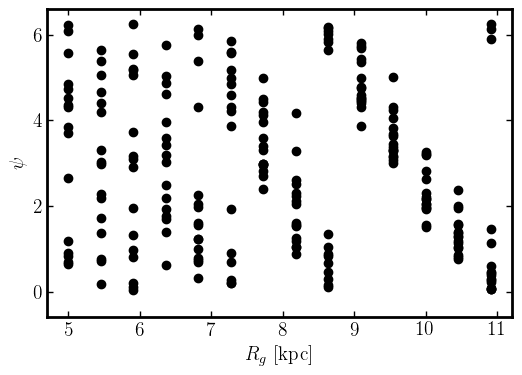

In [198]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.scatter(tbl_time_sub['jphi_cen'] / 220, tbl_time_sub['phase600']%(2*np.pi))
ax.set_ylim(-0.6, 2.1*np.pi)
ax.set_xlabel(r'$R_g$ [kpc]')
ax.set_ylabel(r'$\psi$')
plt.show()

In [236]:
220*11

2420

In [199]:
jphi_c = np.linspace(1100, 2400, 14)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

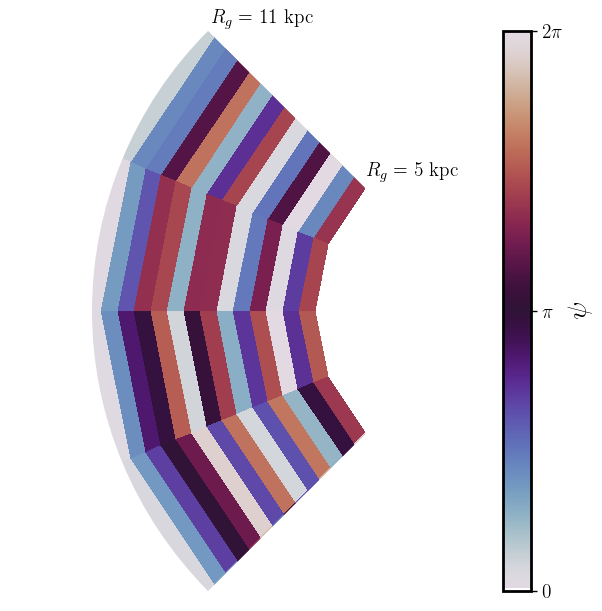

In [237]:
tbl_time_sub = tbl[(tbl['timestep']==65) & (tbl['jphi_cen']>1050) & (tbl['jphi_cen']<2450)]

fig, ax = plt.subplots(1,1, figsize=(7,6), constrained_layout=True, subplot_kw={'projection':'polar'})
dat = np.reshape(tbl_time_sub['phase600']%(2*np.pi), T.shape, 'F')
im = ax.pcolormesh(T,J, dat, cmap=cm.twilight,
                           norm=mpl.colors.Normalize(), rasterized=True)
ax.text(3*np.pi/4-0.05, 1100, r' $R_g = 5$ kpc')
ax.text(3*np.pi/4-0.02, 2420, r' $R_g = 11$ kpc')
ax.axis('off')
cbar = plt.colorbar(im, pad=-0.1)
cbar.set_label(r'$\psi$', fontsize=20)
cbar.ax.tick_params(direction='out')
cbar.ax.set_yticks([0, np.pi, 2*np.pi])
cbar.ax.set_yticklabels([r'$0$',r'$\pi$',r'$2\pi$']) 
ax.set_yticks([1100, 2400], 
                      labels=['5 kpc', r'11 kpc'], 
                      fontsize=16, color='k')
ax.set_rmax(2400)
ax.set_thetalim(np.pi-np.pi/4, np.pi+np.pi/4)
ax.tick_params(left = False, right = False , labelleft = True ,
                     labelbottom = False, bottom = False)      
ax.grid(visible=False)
# ax.spines['polar'].set_visible(False)
ax.set_rlabel_position(45)
plt.savefig('../../figures/test_sim_phase.pdf')

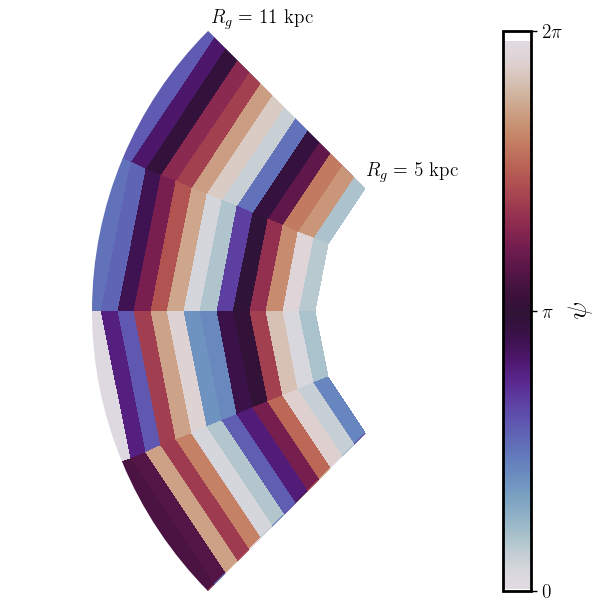

In [241]:
tbl_time_sub = tbl[(tbl['timestep']==50) & (tbl['jphi_cen']>1050) & (tbl['jphi_cen']<2450)]

fig, ax = plt.subplots(1,1, figsize=(7,6), constrained_layout=True, subplot_kw={'projection':'polar'})
dat = np.reshape(tbl_time_sub['phase600']%(2*np.pi), T.shape, 'F')
im = ax.pcolormesh(T,J, dat, cmap=cm.twilight,
                           norm=mpl.colors.Normalize(), rasterized=True)
ax.text(3*np.pi/4-0.05, 1100, r' $R_g = 5$ kpc')
ax.text(3*np.pi/4-0.02, 2420, r' $R_g = 11$ kpc')
ax.axis('off')
cbar = plt.colorbar(im, pad=-0.1)
cbar.set_label(r'$\psi$', fontsize=20)
cbar.ax.tick_params(direction='out')
cbar.ax.set_yticks([0, np.pi, 2*np.pi])
cbar.ax.set_yticklabels([r'$0$',r'$\pi$',r'$2\pi$']) 
ax.set_yticks([1100, 2400], 
                      labels=['5 kpc', r'11 kpc'], 
                      fontsize=16, color='k')
ax.set_rmax(2400)
ax.set_thetalim(np.pi-np.pi/4, np.pi+np.pi/4)
ax.tick_params(left = False, right = False , labelleft = True ,
                     labelbottom = False, bottom = False)      
ax.grid(visible=False)
# ax.spines['polar'].set_visible(False)
ax.set_rlabel_position(45)
# plt.savefig('../../figures/test_sim_phase.pdf')

## Finer grid

In [244]:
t = Table.read('../data/test_data_t65_for_axel.fits')

jphi_c = np.linspace(1130, 2390, 22)
tphi_c_ = np.arange(3*np.pi/4+np.pi/32, 5*np.pi/4, np.pi/16)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
centers = np.array(np.meshgrid(jphi_c, tphi_c)).T.reshape(-1,2)
J, T = np.meshgrid(jphi_c, tphi_c)

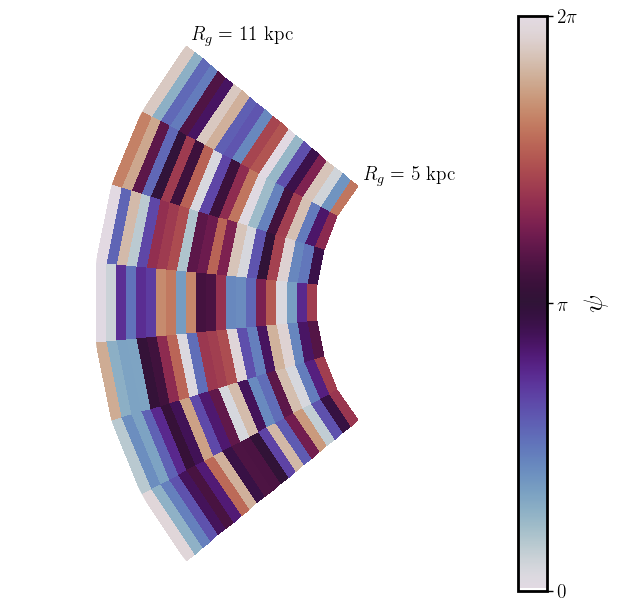

In [246]:
fig, ax = plt.subplots(1,1, figsize=(7,6), constrained_layout=True, subplot_kw={'projection':'polar'})
dat = np.reshape(t['phase600']%(2*np.pi), T.shape, 'F')
im = ax.pcolormesh(T,J, dat, cmap=cm.twilight,
                           norm=mpl.colors.Normalize(), rasterized=True)
ax.text(3*np.pi/4+0.05, 1100, r' $R_g = 5$ kpc')
ax.text(3*np.pi/4+0.08, 2420, r' $R_g = 11$ kpc')
ax.axis('off')
cbar = plt.colorbar(im, pad=-0.1)
cbar.set_label(r'$\psi$', fontsize=20)
cbar.ax.tick_params(direction='out')
cbar.ax.set_yticks([0, np.pi, 2*np.pi])
cbar.ax.set_yticklabels([r'$0$',r'$\pi$',r'$2\pi$']) 
ax.set_yticks([1100, 2420], 
                      labels=['5 kpc', r'11 kpc'], 
                      fontsize=16, color='k')
ax.set_rmax(2420)
ax.set_thetalim(np.pi-np.pi/4, np.pi+np.pi/4)
ax.tick_params(left = False, right = False , labelleft = True ,
                     labelbottom = False, bottom = False)      
ax.grid(visible=False)
# ax.spines['polar'].set_visible(False)
ax.set_rlabel_position(45)
plt.savefig('../../figures/test_sim_phase.pdf')